In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy.optimize import minimize
from termcolor import colored

## Import des données

In [2]:
df = pd.read_parquet("data/votes.parquet")
df.head()

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,112580,2025-10-28 17:02:44.266579,gemini-2.5-flash,grok-4-fast,"[gemini-2.5-flash, grok-4-fast]",NaN,crée des cartes types dixit sur le thème des m...,True,[{'content': 'crée des cartes types dixit sur ...,[{'content': 'crée des cartes types dixit sur ...,...,False,False,False,False,False,False,NaN,NaN,False,False
1,55251,2025-04-22 18:07:44.914551,gemma-3-4b,c4ai-command-r-08-2024,"[c4ai-command-r-08-2024, gemma-3-4b]",gemma-3-4b,J'ai lu quelque part (je ne sais pas où) qu'ut...,False,[{'content': 'J'ai lu quelque part (je ne sais...,[{'content': 'J'ai lu quelque part (je ne sais...,...,False,False,False,True,False,False,NaN,NaN,True,False
2,56377,2025-04-28 08:47:19.683661,phi-4,llama-3.1-405b,"[llama-3.1-405b, phi-4]",NaN,créer un texte sur le degrés d'intégration des...,True,[{'content': 'créer un texte sur le degrés d'i...,[{'content': 'créer un texte sur le degrés d'i...,...,False,False,False,False,False,False,NaN,NaN,False,False
3,64275,2025-05-17 05:45:36.035179,phi-4,gemma-3-27b,"[gemma-3-27b, phi-4]",gemma-3-27b,Coucou,False,"[{'content': 'Coucou ', 'metadata': None, 'rea...","[{'content': 'Coucou ', 'metadata': None, 'rea...",...,False,False,False,False,False,False,NaN,NaN,False,False
4,30173,2025-02-24 15:05:34.404003,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,"[chocolatine-2-14b-instruct-v2.0.3-q8, gpt-4o-...",gpt-4o-2024-08-06,Je souhaite élaborer des routines qui me perme...,False,[{'content': 'Tu es un assistant IA serviable ...,[{'content': 'Je souhaite élaborer des routine...,...,False,False,False,False,False,False,,Tu es un assistant IA serviable et bienveillan...,False,False


## Classement global

In [3]:
# Construction de la matrice de comparaison
df_filtered = df[df["both_equal"] == False]
print(f"Nombre de votes restants après filtrage `both_equal`: {len(df_filtered)}/{len(df)} ({100*len(df_filtered)/len(df):.2f}%)")
df_filtered[["model_a_name", "model_b_name"]].head()

Nombre de votes restants après filtrage `both_equal`: 94939/157132 (60.42%)


,model_a_name,model_b_name
1,gemma-3-4b,c4ai-command-r-08-2024
3,phi-4,gemma-3-27b
4,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06
5,llama-3.3-70b,llama-4-scout
6,grok-3-mini-beta,qwen3-32b


Top 10 des modèles les plus présents après filtrage `both_equal`:
model_a_name
llama-3.3-70b                 5232
gemma-3-4b                    5206
phi-4                         4842
gemma-3-27b                   4720
gemma-3-12b                   4627
gemini-2.0-flash              4595
mistral-large-2411            4332
llama-3.1-8b                  4328
command-a                     4042
ministral-8b-instruct-2410    4022
Name: count, dtype: int64


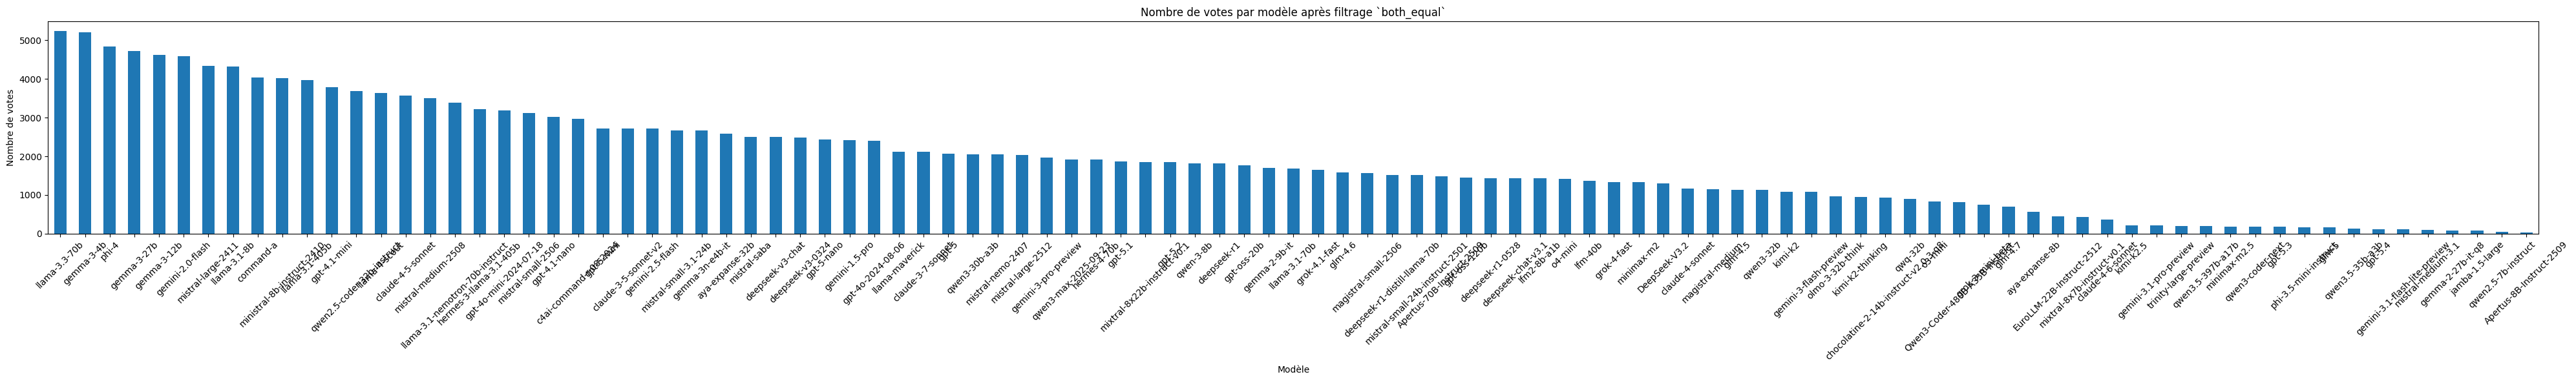

count     101.000000
mean     1879.980198
std      1363.203968
min        34.000000
25%       902.000000
50%      1687.000000
75%      2662.000000
max      5232.000000
Name: count, dtype: float64

In [4]:
def get_occurences_model(df:pd.DataFrame) -> pd.Series:
    """Récupère les modèles et leur nombre d'occurrences dans les colonnes `model_a_name` et `model_b_name`."""
    model_names_a = df["model_a_name"].value_counts()
    model_names_b = df["model_b_name"].value_counts()

    # Mise en commun des deux séries
    return model_names_a.add(model_names_b, fill_value=0).sort_values(ascending=False)

model_names = get_occurences_model(df_filtered)
print("Top 10 des modèles les plus présents après filtrage `both_equal`:")
print(model_names.head(10))

# Affichage de l'histogramme
fig = plt.figure(figsize=(40, 6))
model_names.plot(kind="bar")
plt.title("Nombre de votes par modèle après filtrage `both_equal`")
plt.xlabel("Modèle")
plt.ylabel("Nombre de votes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Détail
model_names.describe()

In [5]:
def build_ranking(model_names:list[str], df:pd.DataFrame) -> np.ndarray:
    """
    Construit la matrice de gain où W[i, j] est le nombre de fois que le modèle i a été préféré au modèle j dans les votes.
    """
    gains = np.zeros((len(model_names), len(model_names)), dtype=int)
    for row in df.itertuples():
        if row.model_a_name in model_names and row.model_b_name in model_names:
            i = model_names.index(row.model_a_name)
            j = model_names.index(row.model_b_name)
            if i == j:
                continue
            if row.chosen_model_name == row.model_a_name:
                gains[i, j] += 1
            elif row.chosen_model_name == row.model_b_name:
                gains[j, i] += 1
    return gains

### Recherche du nombre de modèles $N$ optimal

In [6]:
# Choix du nombre minimum d'occurence du modèle pour être inclus dans l'analyse
n_grid_search = np.arange(0, 1500, 100)

results = {}
for n in tqdm(n_grid_search, desc="Grid search on n"):
    eligible = model_names[model_names >= n].index
    sub = df_filtered[
        df_filtered["model_a_name"].isin(eligible) & df_filtered["model_b_name"].isin(eligible)
    ]
    model_counts = get_occurences_model(sub)
    gains = build_ranking(list(eligible), sub)
    nb_duels = (gains+gains.T) / 2
    triu = np.triu(np.ones((len(eligible), len(eligible))), k=1)
    duels = nb_duels[triu == 1].flatten()
    results[n] = {
        "n_votes": len(sub),
        "n_models": len(model_counts),
        "min_votes_per_model": model_counts.min(),
        "max_votes_per_model": model_counts.max(),
        "mean_votes_per_model": model_counts.mean(),
        "ratio_pairs_with_duels": np.sum(duels > 0) / len(duels)
    }

Grid search on n: 100%|██████████| 15/15 [00:29<00:00,  1.96s/it]


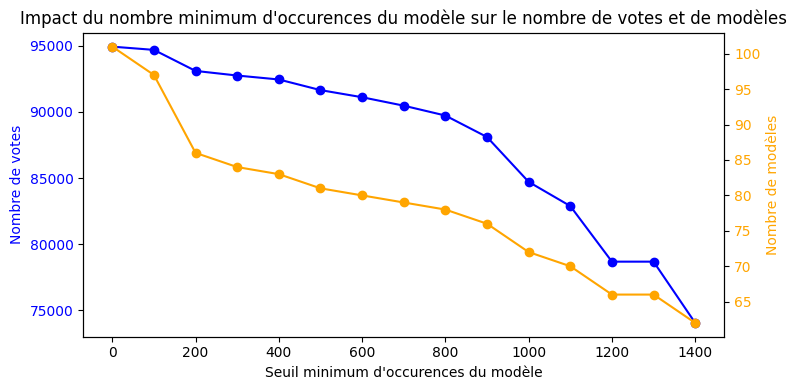

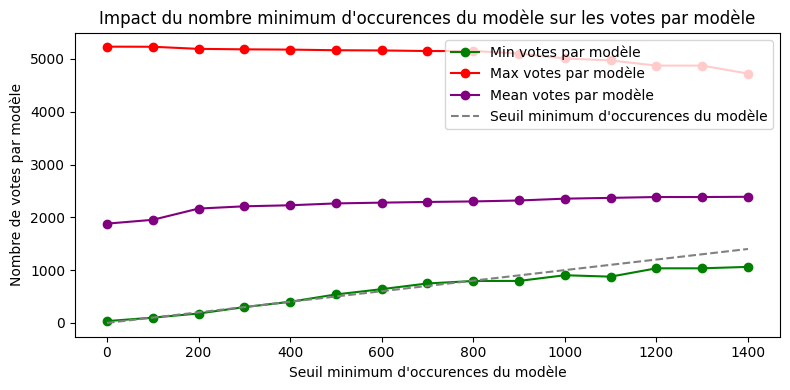

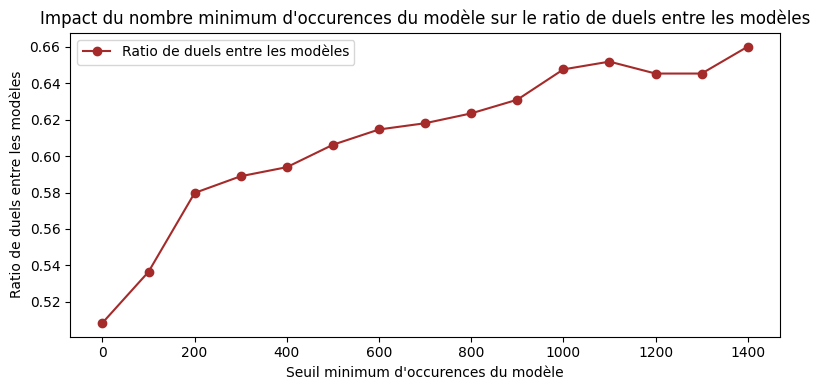

In [7]:
# Nombre de votes et de modèles en fonction du seuil minimum d'occurences du modèle
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(n_grid_search, [results[n]["n_votes"] for n in n_grid_search], color="blue", marker="o", label="Nombre de votes")
ax2.plot(n_grid_search, [results[n]["n_models"] for n in n_grid_search], color="orange", marker="o", label="Nombre de modèles")
ax1.set_xlabel("Seuil minimum d'occurences du modèle")
ax1.set_ylabel("Nombre de votes", color="blue")
ax2.set_ylabel("Nombre de modèles", color="orange")
ax1.tick_params(axis="y", labelcolor="blue")
ax2.tick_params(axis="y", labelcolor="orange")
ax1.set_title("Impact du nombre minimum d'occurences du modèle sur le nombre de votes et de modèles")
fig.tight_layout()
plt.show()

# Nombre d'occurrence min, max et mean par modèle en fonction du seuil minimum d'occurences du modèle
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_grid_search, [results[n]["min_votes_per_model"] for n in n_grid_search], color="green", marker="o", label="Min votes par modèle")
ax.plot(n_grid_search, [results[n]["max_votes_per_model"] for n in n_grid_search], color="red", marker="o", label="Max votes par modèle")
ax.plot(n_grid_search, [results[n]["mean_votes_per_model"] for n in n_grid_search], color="purple", marker="o", label="Mean votes par modèle")
ax.plot(n_grid_search, n_grid_search, color="gray", linestyle="--", label="Seuil minimum d'occurences du modèle")
ax.set_xlabel("Seuil minimum d'occurences du modèle")
ax.set_ylabel("Nombre de votes par modèle")
ax.set_title("Impact du nombre minimum d'occurences du modèle sur les votes par modèle")
ax.legend()
fig.tight_layout()
plt.show()

# Ratio de duels entre les modèles en fonction du seuil minimum d'occurences du modèle
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_grid_search, [results[n]["ratio_pairs_with_duels"] for n in n_grid_search], color="brown", marker="o", label="Ratio de duels entre les modèles")
ax.set_xlabel("Seuil minimum d'occurences du modèle")
ax.set_ylabel("Ratio de duels entre les modèles")
ax.set_title("Impact du nombre minimum d'occurences du modèle sur le ratio de duels entre les modèles")
ax.legend()
fig.tight_layout()
plt.show()

### Calcul de la matrice de gains et du classement

In [8]:
# On peut fixer jusqu'à N=800 pour que le nombre de votes par modèles soit satisfait,
# maximiser tout de même le nombre de duels entre les modèles,
# et éviter d'avoir trop peu de modèles pour l'analyse
models = list(model_names[model_names >= 800].index)
print(f"Nombre final de modèles retenus pour l'analyse: {len(models)}")

Nombre final de modèles retenus pour l'analyse: 78


In [9]:
gains = build_ranking(models, df_filtered)
gains

array([[  0,  80, 127, ...,  15,  10,  11],
       [146,   0,  98, ...,   7,  14,   9],
       [ 83,  58,   0, ...,  10,   7,   0],
       ...,
       [  9,   5,   8, ...,   0,  33,   0],
       [ 13,   7,  12, ...,  36,   0,   0],
       [ 13,  11,   0, ...,   0,   0,   0]], shape=(78, 78))

In [10]:
def estimate_bradley_terry(W:np.ndarray):
    """
    Estime les paramètres β du modèle de Bradley-Terry à partir de la matrice de gains W.

    Args:
        W (np.ndarray): Matrice de gains, W[i,j] = nombre de fois que i bat j.

    Returns:
        np.ndarray: Paramètres β estimés pour chaque modèle.
        np.ndarray: Classement des modèles (indices des modèles par ordre décroissant de β).
    """
    n_models = W.shape[0]
    beta_init = np.ones(n_models)

    def log_likelihood(beta, W):
        likelihood = 0.0
        for i in range(n_models):
            for j in range(n_models):
                if i != j:
                    p = beta[i] / (beta[i] + beta[j])
                    likelihood += W[i, j] * np.log(p)
        return -likelihood  # On minimise l'opposé de la log-vraisemblance

    result = minimize(log_likelihood, beta_init, args=(W,), method='L-BFGS-B')
    beta_estimated = result.x
    ranking = np.argsort(beta_estimated)[::-1]

    return beta_estimated, ranking

In [11]:
beta_global, ranking_global = estimate_bradley_terry(gains)
print("Classement global des modèles (indices):", ranking_global)
print("Top 10 du classement global des modèles (noms):", [models[i] for i in ranking_global][:5])

/tmp/ipykernel_91498/964094502.py:21: RuntimeWarning: invalid value encountered in log
  likelihood += W[i, j] * np.log(p)


Classement global des modèles (indices): [ 5 15 29 24  3 30 39  4 41 16  8 14 67 32 71 40 35  6  1 47 63 19 43 57
 59 66 51 68 58 73 55 77 65 26 11 53 70 52 45 28 76 50 25 69 18 13 23 34
 61 75 48 60 49 33 64 27  0 54 22 56  9 37 46  2 20 36 62  7 74 17 10 72
 42 21 12 44 31 38]
Top 10 du classement global des modèles (noms): ['gemini-2.0-flash', 'mistral-medium-2508', 'deepseek-v3-chat', 'gemini-2.5-flash', 'gemma-3-27b']


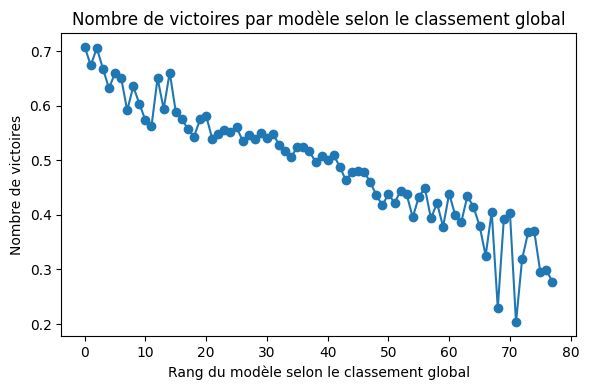

In [12]:
def plot_wins_by_ranking(gains:np.ndarray, ranking:np.ndarray, models:list[str], ranking_name:str):
    ratio_wins = (gains.sum(axis=1) / (gains.sum(axis=1) + gains.sum(axis=0)))[ranking]
    plt.figure(figsize=(6, 4))
    plt.plot(range(len(models)), ratio_wins, marker="o", linestyle="-")
    plt.xlabel(f"Rang du modèle selon le {ranking_name}")
    plt.ylabel("Nombre de victoires")
    plt.title(f"Nombre de victoires par modèle selon le {ranking_name}")
    plt.tight_layout()
    plt.show()

plot_wins_by_ranking(gains, ranking_global, models, ranking_name="classement global")

## Classement de la créativité

In [13]:
def build_creative_ranking(model_names:list[str], df:pd.DataFrame) -> np.ndarray:
    """
    Construit la matrice de gain où W[i, j] est le nombre de fois que le modèle i a été préféré au modèle j dans les votes créatifs.
    """
    gains = np.zeros((len(model_names), len(model_names)), dtype=int)
    for row in df.itertuples():
        if row.conv_creative_a or row.conv_creative_b:
            if row.model_a_name in model_names and row.model_b_name in model_names:
                i = model_names.index(row.model_a_name)
                j = model_names.index(row.model_b_name)
                if row.conv_creative_a and not row.conv_creative_b:
                    gains[i, j] += 1
                elif row.conv_creative_b and not row.conv_creative_a:
                    gains[j, i] += 1
    return gains

In [14]:
df_crea_filtered = df[df[["conv_creative_a", "conv_creative_b"]].any(axis=1)]
print(f"Nombre de votes restants après filtrage `creative`: {len(df_crea_filtered)}/{len(df)} ({100*len(df_crea_filtered)/len(df):.2f}%)")

Nombre de votes restants après filtrage `creative`: 11069/157132 (7.04%)


In [15]:
creative_gains = build_creative_ranking(models, df_crea_filtered)
creative_gains

array([[ 0,  1,  9, ...,  1,  3,  2],
       [15,  0,  9, ...,  0,  1,  0],
       [ 5,  3,  1, ...,  1,  0,  0],
       ...,
       [ 3,  0,  0, ...,  0,  5,  0],
       [ 0,  0,  1, ...,  1,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(78, 78))

In [16]:
beta_creative, ranking_creative = estimate_bradley_terry(creative_gains)
print("Classement créatif des modèles (indices):", ranking_creative)
print("Top 10 du classement créatif des modèles (noms):", [models[i] for i in ranking_creative][:5])

/tmp/ipykernel_91498/964094502.py:21: RuntimeWarning: invalid value encountered in log
  likelihood += W[i, j] * np.log(p)


Classement créatif des modèles (indices): [ 5 32  3 16 30 47  1  4 15 29 49 39 40 24 51 48 58 70 69 75 65 41 59 57
 26 68 35 52 77 23 11 71  8 66 63 73 54 14 67 50 36 76 43 64 19 46 61 53
 55 31 37 45 33 10 28 13 72 56 60 42 74 34 22 18 62  6 21 27  0 25 20  2
  9 17  7 12 44 38]
Top 10 du classement créatif des modèles (noms): ['gemini-2.0-flash', 'gemini-1.5-pro', 'gemma-3-27b', 'llama-3.1-nemotron-70b-instruct', 'deepseek-v3-0324']


/tmp/ipykernel_91498/899221424.py:2: RuntimeWarning: invalid value encountered in divide
  ratio_wins = (gains.sum(axis=1) / (gains.sum(axis=1) + gains.sum(axis=0)))[ranking]


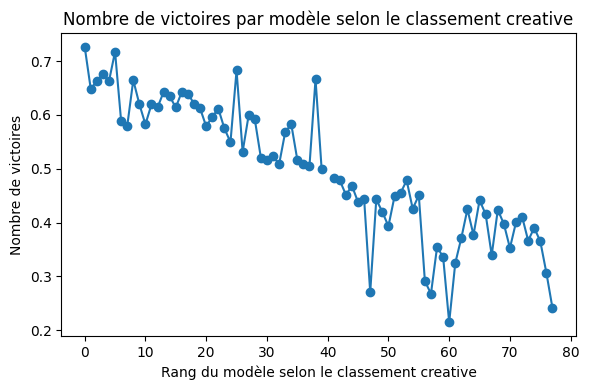

In [17]:
plot_wins_by_ranking(creative_gains, ranking_creative, models, ranking_name="classement creative")

## Différence entre les classements

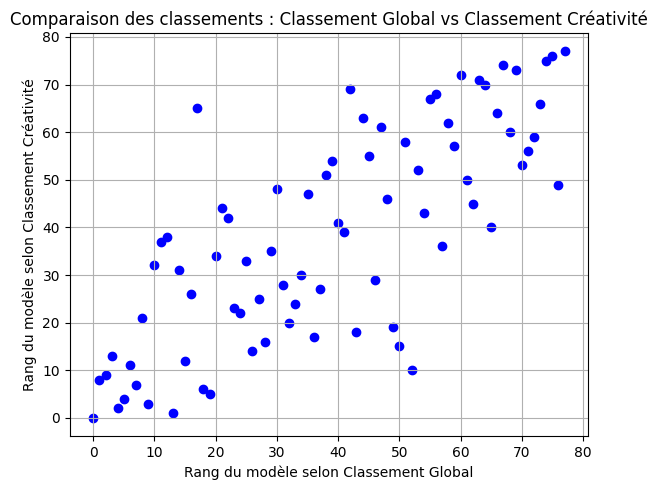

Coefficient de Spearman : 0.047
P-value : 0.682

Top 10 des pires changements de rangs :
mistral-large-2411 : Classement Global = 17, Classement Créativité = 65, Différence = 48
gemma-2-9b-it : Classement Global = 52, Classement Créativité = 10, Différence = 42
gpt-oss-20b : Classement Global = 50, Classement Créativité = 15, Différence = 35
qwq-32b : Classement Global = 49, Classement Créativité = 19, Différence = 30
gpt-5-nano : Classement Global = 76, Classement Créativité = 49, Différence = 27
mistral-small-3.1-24b : Classement Global = 42, Classement Créativité = 69, Différence = 27
claude-4-5-sonnet : Classement Global = 11, Classement Créativité = 37, Différence = 26
magistral-medium : Classement Global = 12, Classement Créativité = 38, Différence = 26
qwen3-32b : Classement Global = 43, Classement Créativité = 18, Différence = 25
gpt-5 : Classement Global = 65, Classement Créativité = 40, Différence = 25


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def compare_rankings(ranking1, ranking2, models, title1="Classement 1", title2="Classement 2"):
    """
    Compare deux classements en calculant leur corrélation de Spearman
    et en affichant une visualisation côte à côte.

    Args:
        ranking1 (np.ndarray): Premier classement (indices des modèles).
        ranking2 (np.ndarray): Deuxième classement (indices des modèles).
        title1 (str): Titre du premier classement.
        title2 (str): Titre du deuxième classement.
    """
    # Calcul du coefficient de corrélation de Spearman
    spearman_corr, p_value = spearmanr(ranking1, ranking2)

    # Visualisation des classements
    plt.figure(figsize=(6, 5))

    # Classement 1 en fonction du classement 2
    ranks_1_by_model = np.argsort(ranking1)
    ranks_2_by_model = np.argsort(ranking2)
    plt.scatter(ranks_1_by_model, ranks_2_by_model, color='blue')
    plt.title(f"Comparaison des classements : {title1} vs {title2}")
    plt.xlabel(f"Rang du modèle selon {title1}")
    plt.ylabel(f"Rang du modèle selon {title2}")
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Affichage du résultat
    print(f"Coefficient de Spearman : {spearman_corr:.3f}")
    print(f"P-value : {p_value:.3f}")

    # Top 5 des pires changement de rangs
    rank_diff = np.abs(ranks_1_by_model - ranks_2_by_model)
    worst_changes = np.argsort(rank_diff)[-10:]
    print("\nTop 10 des pires changements de rangs :")
    for idx in worst_changes[::-1]:
        print(f"{colored(models[idx], "red")} : {title1} = {ranks_1_by_model[idx]}, {title2} = {ranks_2_by_model[idx]}, {colored("Différence", "blue")} = {rank_diff[idx]}")

compare_rankings(ranking_global, ranking_creative, models, "Classement Global", "Classement Créativité")

On observe un coefficient de Spearman de 0.047 ce qui illustre une faible corrélation entre les deux classements.

Parmi les raisons de cette faible corrélation, certains modèles ont des performances très différentes sur les deux classements :
- Bon globalement mais pas créatif : mistral-large-2411, claude-4-5-sonnet, magistral-medium
- Créatif mais moins bon globalement : gemma-2-9b-it, gpt-oss-20b, qwq-32b, gpt-5-nano, mistral-small-3.1-24b